## Customer Retention and Segmentation

This section evaluates customer retention, repeat purchase behavior, and customer segmentation using RFM and cohort analysis to better understand long-term customer engagement.

In [1]:
# Library imports
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Importing needed data
clean_df            = pd.read_csv("data/clean_df.csv", parse_dates=["order_purchase_timestamp", "shipping_limit_date"])
repeat_customers    = pd.read_csv("data/repeat_customers.csv")
customers           = pd.read_csv("data/olist_customers_dataset.csv")

<a id="repeat-purchase-behavior"></a>
### Repeat Purchase Behavior

This analysis evaluates customer retention by measuring how many customers returned to place additional orders.

The goal is to understand repeat purchase behavior and assess the marketplace’s ability to retain customers over time.

In [3]:
# Repeat purchase rate
print(f"Total unique customers:   {len(repeat_customers):,}")
print(f"Repeat customers:         {repeat_customers['is_repeat_customer'].sum():,}")
print(f"Repeat purchase rate:     {repeat_customers['is_repeat_customer'].mean()*100:.2f}%")

# Distribution of order counts
repeat_customers["order_count"].value_counts().sort_index().head(10)

Total unique customers:   93,350
Repeat customers:         2,801
Repeat purchase rate:     3.00%


order_count
1     90549
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

**Note:** Analysis is based on 93,350 customers with at least one delivered order, excluding customers whose orders were cancelled or not yet delivered.

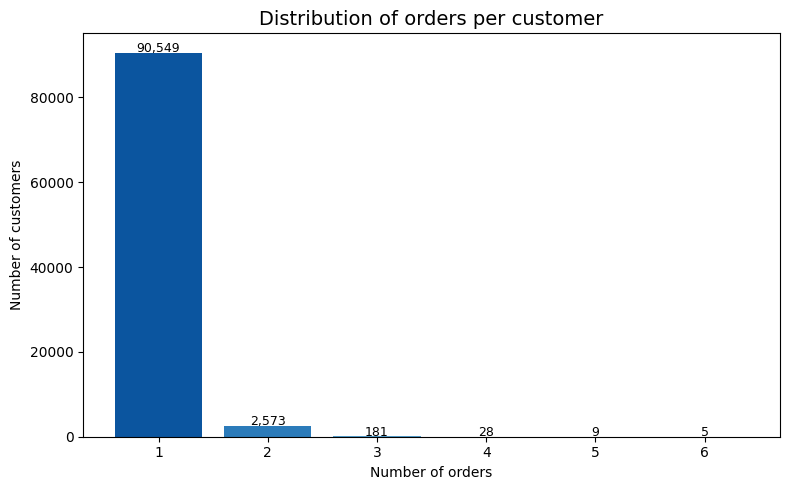

In [4]:
# Order count distribution
fig, ax = plt.subplots(figsize=(8, 5))

order_dist = repeat_customers["order_count"].value_counts().sort_index().head(6)

ax.bar(
    order_dist.index.astype(str),
    order_dist.values,
    color=sns.color_palette("Blues_r", 6)
)

ax.set_title("Distribution of orders per customer", fontsize=14)
ax.set_xlabel("Number of orders")
ax.set_ylabel("Number of customers")
ax.grid(False)

# Value labels on bars
for i, v in enumerate(order_dist.values):
    ax.text(i, v + 100, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("viz_9_repeat_customers.png", dpi=150)
plt.show()

Out of more than 93,000 unique customers, only approximately 3% returned to place additional orders. Most repeat customers made only two purchases, while customers with three or more orders were extremely rare. The results indicate very low customer retention during the observed period.

The marketplace appears to rely heavily on acquiring new customers rather than retaining existing ones.

Improving repeat purchase behavior may represent a major opportunity for long-term revenue growth and customer lifetime value expansion.

Potential retention strategies may include:
- loyalty programs,
- personalized product recommendations,
- post-purchase engagement,
- and targeted remarketing campaigns.

<a id="customer-segmentation-analysis-rfm"></a>
### Customer Segmentation Analysis (RFM)

To better understand customer behavior and purchasing patterns, an RFM (Recency, Frequency, Monetary) analysis was performed.

RFM segmentation groups customers based on:

- **Recency** — how recently a customer made a purchase
- **Frequency** — how often the customer places orders
- **Monetary Value** — how much revenue the customer generates

This approach helps identify high-value customers, low-engagement users, and potential retention risks.

Since the dataset shows relatively low repeat purchase behavior overall, the segmentation model was simplified into five business-oriented customer groups to improve interpretability and stakeholder readability.

In [5]:
# Adding customer_unique_id from customers table
rfm_df = clean_df.merge(
    customers[["customer_id", "customer_unique_id"]], 
    on="customer_id",
    how="left"
)

print(f"Unique customer_id:        {rfm_df['customer_id'].nunique():,}")
print(f"Unique customer_unique_id: {rfm_df['customer_unique_id'].nunique():,}")

Unique customer_id:        96,203
Unique customer_unique_id: 93,096


In [6]:
# Snapshot date — day after last purchase
snapshot_date = rfm_df["order_purchase_timestamp"].max() + dt.timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

# Calculate RFM metrics per unique customer
rfm = (
    rfm_df.groupby("customer_unique_id")
    .agg(
        recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
        frequency=("order_id", "nunique"),
        monetary=("price", "sum")
    )
    .reset_index()
)

print(f"\nRFM table shape: {rfm.shape}")
print(f"\nRFM summary:")
rfm[["recency", "frequency", "monetary"]].describe().round(2)

Snapshot date: 2018-08-30

RFM table shape: (93096, 4)

RFM summary:


,recency,frequency,monetary
count,93096.00,93096.00,93096.00
mean,236.71,1.03,141.57
std,150.94,0.21,215.77
min,1.00,1.00,0.85
25%,114.00,1.00,47.65
50%,218.00,1.00,89.70
75%,345.00,1.00,154.16
max,602.00,15.00,13440.00


In [7]:
# RFM scores 1-5
rfm["r_score"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1])
rfm["f_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]
)
rfm["m_score"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5])

# Combined RFM score
rfm["rfm_score"] = (
    rfm["r_score"].astype(int)
    + rfm["f_score"].astype(int)
    + rfm["m_score"].astype(int)
)

print(f"RFM shape: {rfm.shape}")
print(f"\nScore distribution:")
rfm["rfm_score"].value_counts().sort_index()

RFM shape: (93096, 8)

Score distribution:


rfm_score
3       840
4      2389
5      4736
6      7666
7     11165
8     13250
9     13960
10    13037
11    10779
12     7383
13     4560
14     2372
15      959
Name: count, dtype: int64

In [8]:
# Customer segmentation based on RFM scores
def label_segment(row):
    r = int(row["r_score"])
    f = int(row["f_score"])
    m = int(row["m_score"])

    if r >= 4 and f >= 4:
        return "Champions"
    elif r >= 3 and f >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "New / Recent Customers"
    elif r <= 2 and f >= 3:
        return "At Risk"
    else:
        return "Low Engagement"

rfm["segment"] = rfm.apply(label_segment, axis=1)

# Segment summary
segment_summary = (
    rfm.groupby("segment")
    .agg(
        customers=("customer_unique_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        total_revenue=("monetary", "sum")
    )
    .round(2)
    .sort_values("customers", ascending=False)
)

segment_summary["customers_pct"] = (
    segment_summary["customers"] / segment_summary["customers"].sum() * 100
).round(2)

segment_summary

,customers,avg_recency,avg_frequency,avg_monetary,total_revenue,customers_pct
segment,,,,,,
Low Engagement,22258,336.05,1.00,138.03,3072281.63,23.91
At Risk,22077,392.64,1.05,143.62,3170748.60,23.71
Loyal Customers,18823,168.81,1.03,137.88,2595305.04,20.22
New / Recent Customers,14981,90.89,1.00,139.30,2086872.31,16.09
Champions,14957,90.22,1.09,150.74,2254570.37,16.07


The RFM analysis reveals several important patterns in customer behavior and retention dynamics within the ecommerce platform.

- The average purchase frequency is very low across all customer segments (~1 order per customer), indicating that most customers purchase only once.

- Nearly half of all customers belong to the **Low Engagement** or **At Risk** segments, suggesting weak customer retention and limited repeat purchasing behavior.

- Even the **Champions** segment demonstrates relatively low repeat activity (average frequency = 1.09), meaning that strong customer loyalty has not yet been fully established.

- A significant share of newly acquired customers fail to transition into loyal repeat buyers, highlighting opportunities for improving post-purchase engagement and retention strategies.

The analysis suggests that the business currently relies more heavily on customer acquisition than long-term customer retention. Improving customer loyalty programs, personalized marketing, and post-purchase engagement may help increase repeat purchase rates and long-term customer lifetime value.

**Recommendations**

- Improve customer retention initiatives through loyalty programs and personalized offers.
- Increase post-purchase engagement to encourage repeat purchases.
- Analyze factors driving one-time purchases and customer churn.

<a id="cohort-retention-analysis"></a>
### Cohort Retention Analysis

To better understand customer retention behavior over time, a cohort analysis was performed.

Customers were grouped into cohorts based on the month of their first purchase (`cohort_month`). Retention was then measured by tracking how many customers returned to place additional orders in subsequent months.

`cohort_index` represents the number of months since a customer's first purchase:
- `0` = acquisition month
- `1` = one month after first purchase
- `2` = two months later
- etc.
  
This analysis helps evaluate:

- customer retention trends
- repeat purchasing behavior
- long-term customer engagement
- sustainability of customer acquisition efforts
  
The retention matrix below shows the percentage of customers from each acquisition cohort who returned in future months.

In [9]:
cohort_df = rfm_df.copy()

cohort_df["order_month"] = cohort_df["order_purchase_timestamp"].dt.to_period("M")
cohort_df["cohort_month"] = cohort_df.groupby("customer_unique_id")["order_month"].transform("min")

cohort_df["cohort_index"] = (
    (cohort_df["order_month"].dt.year - cohort_df["cohort_month"].dt.year) * 12 +
    (cohort_df["order_month"].dt.month - cohort_df["cohort_month"].dt.month)
)

cohort_data = (
    cohort_df.groupby(["cohort_month", "cohort_index"])["customer_unique_id"]
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_data.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customer_unique_id"
)

cohort_retention = cohort_pivot.divide(cohort_pivot[0], axis=0) * 100
(
    cohort_retention.round(2)
    .style
    .background_gradient(cmap="Blues", axis=None, vmin=0, vmax=1)
    .format("{:.2f}%", na_rep="-")
    .set_caption("Cohort retention rate (%)")
)

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19
cohort_month,,,,,,,,,,,,,,,,,,,
2017-01,100.00%,0.28%,0.28%,0.14%,0.42%,0.14%,0.42%,0.14%,0.14%,-,0.42%,0.14%,0.70%,0.42%,0.14%,0.14%,0.28%,0.42%,0.14%
2017-02,100.00%,0.18%,0.31%,0.12%,0.43%,0.12%,0.25%,0.18%,0.12%,0.18%,0.12%,0.31%,0.12%,0.18%,0.12%,0.06%,0.06%,0.18%,-
2017-03,100.00%,0.44%,0.36%,0.40%,0.36%,0.16%,0.16%,0.32%,0.32%,0.08%,0.36%,0.12%,0.20%,0.12%,0.16%,0.24%,0.08%,0.12%,-
2017-04,100.00%,0.62%,0.22%,0.18%,0.27%,0.27%,0.35%,0.31%,0.31%,0.18%,0.27%,0.09%,0.04%,0.04%,0.09%,0.09%,0.13%,-,-
2017-05,100.00%,0.46%,0.46%,0.29%,0.29%,0.32%,0.41%,0.14%,0.26%,0.26%,0.26%,0.35%,0.23%,0.03%,0.17%,0.20%,-,-,-
2017-06,100.00%,0.49%,0.40%,0.43%,0.30%,0.40%,0.36%,0.23%,0.13%,0.20%,0.30%,0.36%,0.16%,0.16%,0.23%,-,-,-,-
2017-07,100.00%,0.53%,0.35%,0.24%,0.29%,0.21%,0.32%,0.11%,0.19%,0.27%,0.21%,0.29%,0.13%,0.24%,-,-,-,-,-
2017-08,100.00%,0.69%,0.35%,0.27%,0.35%,0.52%,0.30%,0.27%,0.15%,0.15%,0.25%,0.20%,0.12%,-,-,-,-,-,-
2017-09,100.00%,0.70%,0.55%,0.27%,0.45%,0.22%,0.22%,0.25%,0.27%,0.20%,0.25%,0.07%,-,-,-,-,-,-,-


**Key Findings**

- Customer retention drops sharply after the acquisition month across nearly all cohorts.

- Most cohorts retain only a very small percentage of customers after the first purchase, confirming weak repeat purchasing behavior.

- Retention patterns remain consistently low across both 2017 and 2018 cohorts, suggesting that low customer retention is a structural characteristic of the platform rather than a temporary anomaly.

- No significant improvement in retention is observed across newer customer cohorts, indicating that customer loyalty and long-term engagement remained relatively unchanged over time.

The business currently appears to operate with an acquisition-driven growth model, relying heavily on attracting new customers rather than maximizing long-term customer lifetime value.

Improving retention strategies — such as loyalty programs, personalized recommendations, post-purchase engagement, and remarketing campaigns — could significantly improve customer lifetime value and long-term profitability.

# Conclusions and Business Recommendations

### Key Insights

- Customer retention was extremely low:
  - only around 3% of customers placed more than one order,
  - 97% were one-time buyers.
- Most repeat customers made only two purchases, while customers with three or more orders were very rare.
- RFM analysis showed that the customer base was dominated by `Low Engagement` and `At Risk` segments, which together represented nearly half of all customers.
- High-value segments such as `Champions` and `Loyal Customers` represented a smaller share of users but generated strong revenue contributions.
- `Champions` showed the highest average spending and purchase frequency, making them the most valuable customer segment.
- Cohort retention analysis revealed a sharp drop in retention immediately after the first purchase month across nearly all cohorts.
- Retention patterns remained consistently weak throughout both 2017 and 2018, indicating that low repeat purchasing was a structural characteristic of the business rather than a temporary issue.
- The marketplace appeared to rely primarily on continuous customer acquisition rather than long-term customer retention.

### Business Recommendations

1. **Develop customer retention strategies**  
   Loyalty programs, personalized recommendations, remarketing campaigns, and post-purchase engagement initiatives could help improve repeat purchase behavior.

2. **Focus on high-value customer segments**  
   Retaining `Champions` and `Loyal Customers` may generate higher long-term value than relying mainly on acquiring new users.

3. **Increase post-purchase engagement**  
   Email campaigns, personalized offers, and targeted promotions could encourage second and third purchases.

4. **Investigate drivers of one-time purchasing behavior**  
   The extremely low retention rate suggests possible issues related to customer experience, pricing competitiveness, product quality, or marketplace differentiation.

5. **Track retention KPIs continuously**  
   Monitoring cohort retention and RFM segment movement over time may help measure the effectiveness of future retention initiatives.